# Demo datasets

Adapted by <alberto.suarez@uam.es> from 

Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.
https://scikit-learn.org/stable/index.html
https://scikit-learn.org/stable/auto_examples/index.html#dataset-examples

Version: Final 

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Plotting utilities
import utilities.plot_utilities as pltu

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'utilities.plot_utilities'

## Synthetic datasets

0 <function <lambda> at 0x00000170474E6F70> (0, 1)
1 <function <lambda> at 0x0000017043C8E670> (0, 1)
2 <function <lambda> at 0x00000170471C3CA0> (0, 1)
3 <function <lambda> at 0x00000170471C3C10> (2, 5)


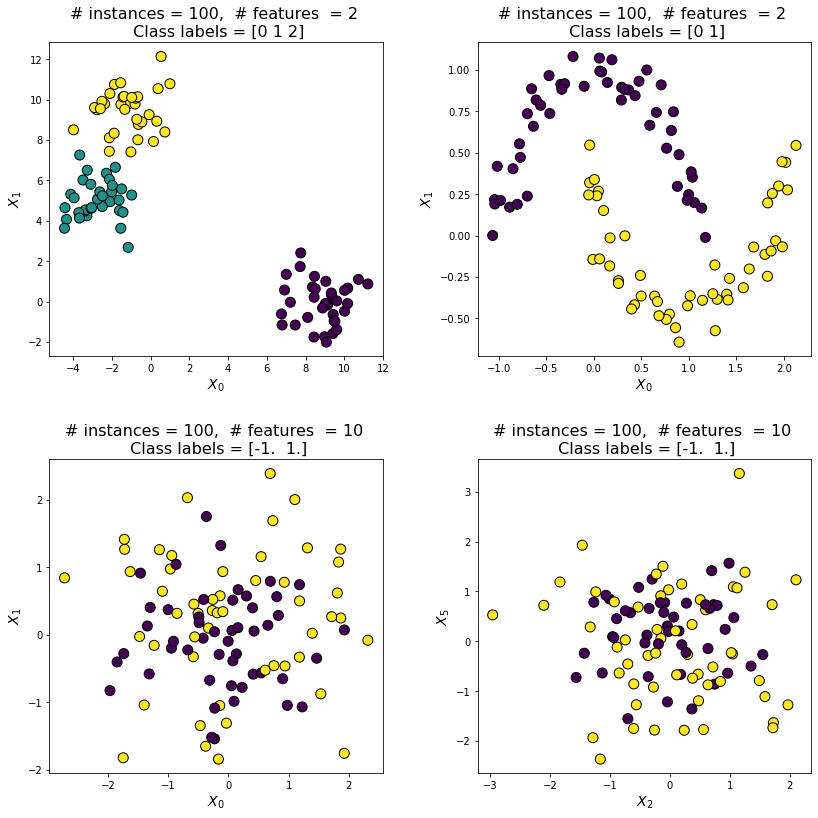

In [28]:
n_samples = 100

make_datasets = [lambda: datasets.make_blobs(n_samples=n_samples, centers=3),
                 lambda: datasets.make_moons(n_samples=n_samples, noise=0.1),
                 lambda: datasets.make_hastie_10_2(n_samples=n_samples),
                 lambda: datasets.make_hastie_10_2(n_samples=n_samples)]

indices = [(0, 1), 
           (0, 1), 
           (0, 1), 
           (2, 5)]

fig, axs = plt.subplots(2, 2, figsize=(12,12))

for n_ax, (make_dataset, indices_features) in enumerate(zip(make_datasets, indices)):
    print(n_ax, make_dataset, indices_features)
    X, y = make_dataset()
    n_row, n_col = a,b = divmod(n_ax, 2)
    pltu.plot_dataset_2D(X, y, indices_features=indices_features, ax=axs[n_row][n_col])
    
fig.tight_layout(pad=3.0)


## The Iris dataset

In [43]:
# Code source: Gaël Varoquaux
# Modified for documentation by Jaques Grobler
#
# adapted by <alberto.suarez@uam.es> 
#
# License: BSD 3 clause

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# The Iris dataset
iris = datasets.load_iris()
X = iris.data  
y = iris.target
print(np.shape(X), np.shape(y))
print(y)

(150, 4) (150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [42]:
print(type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [36]:
# A few samples from the set
samples = np.c_[X, y]

n_samples, n_features = np.shape(X) 

print('Features =', iris.feature_names)
print()
print('Class labels =', iris.target_names)
print()

print(samples[:4, :])  
print(samples[(n_samples // 2):(n_samples//2 + 4), :])
print(samples[-4:, :])


Features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class labels = ['setosa' 'versicolor' 'virginica']

[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]]
[[6.6 3.  4.4 1.4 1. ]
 [6.8 2.8 4.8 1.4 1. ]
 [6.7 3.  5.  1.7 1. ]
 [6.  2.9 4.5 1.5 1. ]]
[[6.3 2.5 5.  1.9 2. ]
 [6.5 3.  5.2 2.  2. ]
 [6.2 3.4 5.4 2.3 2. ]
 [5.9 3.  5.1 1.8 2. ]]


In [46]:
# Randomly permuted data

permutation = np.random.permutation(n_samples)
X = X[permutation, :]
y = y[permutation]

# A few instances from the set
instances = np.c_[X, y]

print(permutation[:5])
print(instances[:5, :])

[ 45 144 133 110  12]
[[5.8 2.7 4.1 1.  1. ]
 [5.7 2.9 4.2 1.3 1. ]
 [5.6 2.9 3.6 1.3 1. ]
 [5.1 3.8 1.9 0.4 0. ]
 [6.5 3.2 5.1 2.  2. ]]


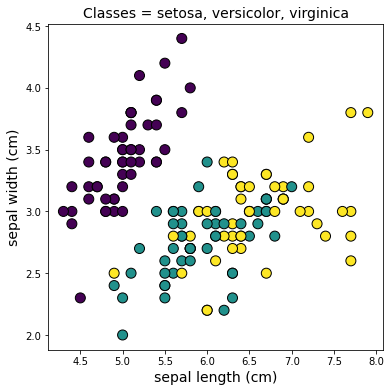

In [6]:
# 2D plot
indices_features = (0, 1, 2)
ax = pltu.plot_dataset_2D(X, y, indices_features=indices_features)

_ = ax.set_xlabel(iris.feature_names[indices_features[0]])
_ = ax.set_ylabel(iris.feature_names[indices_features[1]])

title = 'Classes = '
for name in iris.target_names:
    title += name + ', ' 

fontsize = 14
    
_ = ax.set_title(title[:-2], fontsize=fontsize)

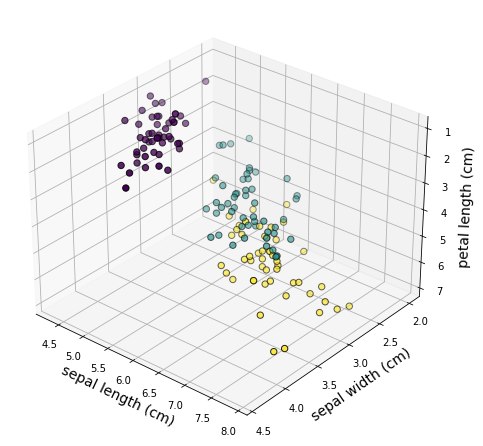

In [7]:
# 3D plot

fig = plt.figure(2, figsize=(8, 6))
ax = Axes3D(fig, elev=-150, azim=-130)
_ = ax.scatter(X[:, indices_features[0]],
               X[:, indices_features[1]], 
               X[:, indices_features[2]], 
               c=y, edgecolor='k', s=40)

fontsize = 14

_ = ax.set_xlabel(iris.feature_names[indices_features[0]],
                  fontsize=fontsize)
_ = ax.set_ylabel(iris.feature_names[indices_features[1]],
                  fontsize=fontsize)
_ = ax.set_zlabel(iris.feature_names[indices_features[2]],
                  fontsize=fontsize)

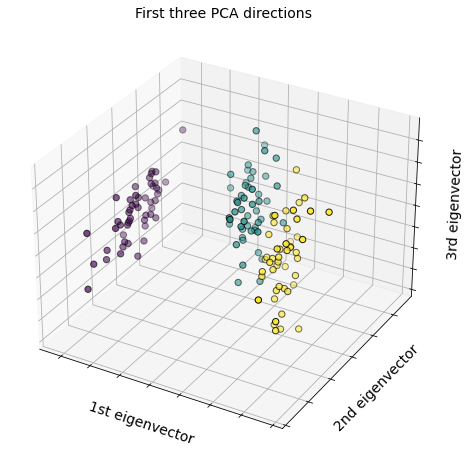

In [8]:
# plot the first three PCA directions
fig = plt.figure(1, figsize=(8, 6))
ax = Axes3D(fig, elev=-150, azim=-120)

X_PCA = PCA(n_components=3).fit_transform(X)
ax.scatter(X_PCA[:, 0], X_PCA[:, 1], X_PCA[:, 2], c=y,
           edgecolor='k', s=40)
ax.set_title("First three PCA directions", fontsize=fontsize)
ax.set_xlabel("1st eigenvector", fontsize=fontsize)
ax.w_xaxis.set_ticklabels([])
ax.set_ylabel("2nd eigenvector", fontsize=fontsize)
ax.w_yaxis.set_ticklabels([])
ax.set_zlabel("3rd eigenvector", fontsize=fontsize)
ax.w_zaxis.set_ticklabels([])

plt.show()


## The German Credit dataset 

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [48]:
# Original data
german_credit_df = pd.read_csv('./data/german_credit_data.csv', sep=';')
german_credit_df.head(4)

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes


In [47]:
# Numerical encoding of the German credit dataset
german_credit_df = pd.read_csv('./data/german_credit_data_numeric.csv', sep=';')
german_credit_df.head(6)

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Class
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
5,4,36,2,91,5,3,3,4,4,35,...,0,0,1,0,0,0,0,1,0,1


In [12]:
# Properties of the Panda's DataFrame

print(type(german_credit_df))

n_samples, n_features = german_credit_df.shape

print('Number of samples = {},     Number of features = {}'.format(
    n_samples, n_features))
      
print(german_credit_df.columns)

<class 'pandas.core.frame.DataFrame'>
Number of samples = 1000,     Number of features = 25
Index(['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10',
       'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20',
       'X21', 'X22', 'X23', 'Class'],
      dtype='object')


In [13]:
# Properties of the Panda's Series

X0 = german_credit_df['X0']
print(X0[:4].T)

print(type(X0))
print(np.shape(X0))

0    1
1    2
2    4
3    1
Name: X0, dtype: int64
<class 'pandas.core.series.Series'>
(1000,)


1 3


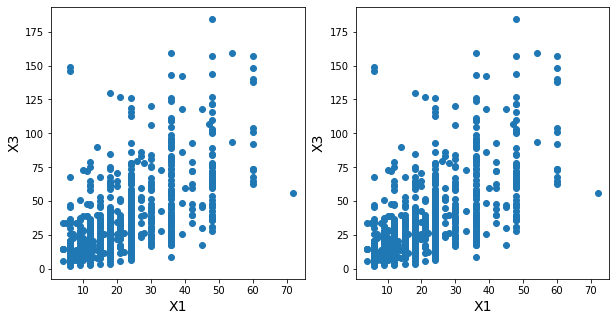

In [14]:
# Visualize the data samples in a 2D attribute space

var_name_x_plot, var_name_y_plot = 'X1', 'X3'

figsize = (10, 5)
fig, axs = plt.subplots(1, 2, num=1, figsize=figsize)

# Access attributes (columns of the DataFrame) by name

_ = axs[0].scatter(german_credit_df[var_name_x_plot], 
                   german_credit_df[var_name_y_plot])

_ = axs[0].set_xlabel(var_name_x_plot,
                      fontsize=fontsize)
_ = axs[0].set_ylabel(var_name_y_plot,
                      fontsize=fontsize)

# Access attributes (columns of the DataFrame)  by index

column_x = german_credit_df.columns.get_loc(var_name_x_plot)
column_y = german_credit_df.columns.get_loc(var_name_y_plot)

print(column_x, column_y)

_ = axs[1].scatter(german_credit_df.iloc[:, column_x], 
                   german_credit_df.iloc[:, column_y])


_ = axs[1].set_xlabel(var_name_x_plot,
                      fontsize=fontsize)
_ = axs[1].set_ylabel(var_name_y_plot,
                      fontsize=fontsize)

In [15]:
# Create a view (not a copy) as a numpy array

print(type(german_credit_df))
print(np.shape(german_credit_df))

<class 'pandas.core.frame.DataFrame'>
(1000, 25)


In [16]:
# Numpy array

german_credit_data = german_credit_df.to_numpy()
print(type(german_credit_data))
print(np.shape(german_credit_data))

<class 'numpy.ndarray'>
(1000, 25)


In [17]:
# WARNING: Only a view (not a copy) is created

print(german_credit_df.iloc[0, 1], german_credit_data[0, 1])
german_credit_data[0, 1] = 5
print(german_credit_df.iloc[0, 1], german_credit_data[0, 1])

6 6
5 5


In [18]:
# Create a DataFrame object from a numpy array

# New list of column names
n_columns = german_credit_data.shape[1]

column_names = []
for n in range(1, n_columns + 1):
    column_names.append('X{}'.format(n))

# New DataFrame object
german_credit_df_modified = pd.DataFrame(german_credit_data, 
                                         columns = column_names)

# Print new column names
print(german_credit_df_modified.columns)


Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'X24', 'X25'],
      dtype='object')


In [19]:
# Save in a CSV file

german_credit_df_modified.to_csv(r'.\data\german_credict_numeric_modified.csv',
                                 sep=';',
                                 index=False, 
                                 header=True)

# Statistical analysis of the data

Adapted by <alberto.suarez@uam.es> 

from
https://scikit-learn.org/stable/auto_examples/inspection/plot_linear_model_coefficient_interpretation.html#sphx-glr-auto-examples-inspection-plot-linear-model-coefficient-interpretation-py


In [20]:
from sklearn.datasets import fetch_openml

# Source: https://www.openml.org/d/534

wages = fetch_openml(data_id=534, as_frame=True)
print(type(wages))
print(type(wages.data))
print(type(wages.target))

<class 'sklearn.utils.Bunch'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [21]:
wages.data.head(4)

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8.0,no,female,21.0,not_member,35.0,Hispanic,Other,Manufacturing,Married
1,9.0,no,female,42.0,not_member,57.0,White,Other,Manufacturing,Married
2,12.0,no,male,1.0,not_member,19.0,White,Other,Manufacturing,Unmarried
3,12.0,no,male,4.0,not_member,22.0,White,Other,Other,Unmarried


In [22]:
# Data matrix
X = wages.data  
X.describe(include="all")

,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,AGE,RACE,OCCUPATION,SECTOR,MARR
count,534.000000,534,534,534.000000,534,534.000000,534,534,534,534
unique,NaN,2,2,NaN,2,NaN,3,6,3,2
top,NaN,no,male,NaN,not_member,NaN,White,Other,Other,Married
freq,NaN,378,289,NaN,438,NaN,440,156,411,350
mean,13.018727,NaN,NaN,17.822097,NaN,36.833333,NaN,NaN,NaN,NaN
std,2.615373,NaN,NaN,12.379710,NaN,11.726573,NaN,NaN,NaN,NaN
min,2.000000,NaN,NaN,0.000000,NaN,18.000000,NaN,NaN,NaN,NaN
25%,12.000000,NaN,NaN,8.000000,NaN,28.000000,NaN,NaN,NaN,NaN
50%,12.000000,NaN,NaN,15.000000,NaN,35.000000,NaN,NaN,NaN,NaN
75%,15.000000,NaN,NaN,26.000000,NaN,44.000000,NaN,NaN,NaN,NaN


In [23]:
# Target values
y = wages.target  
y.describe(include="all")

count    534.000000
mean       9.024064
std        5.139097
min        1.000000
25%        5.250000
50%        7.780000
75%       11.250000
max       44.500000
Name: WAGE, dtype: float64

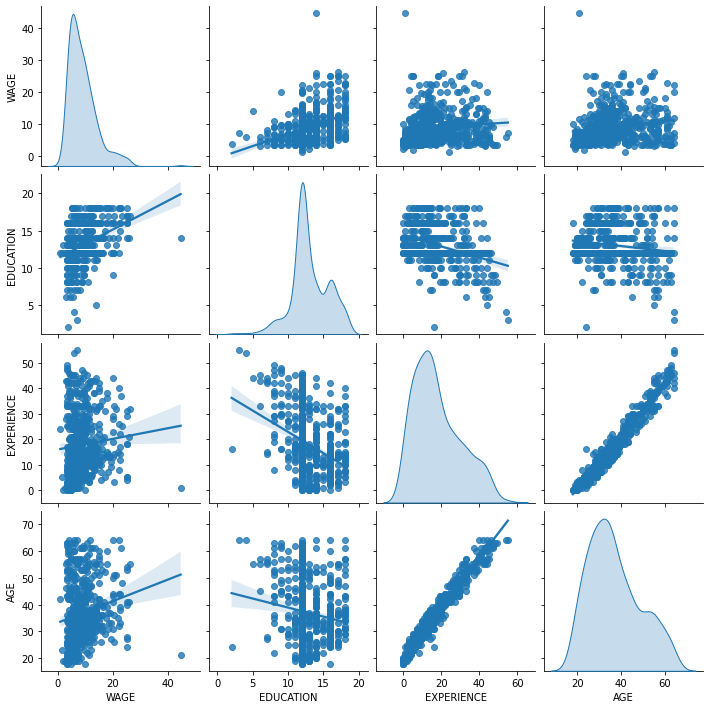

In [24]:
X_y = X.copy()
X_y.insert(0, "WAGE", y)

# Linear regression of target vs. individual attributes
_ = sns.pairplot(X_y, kind='reg', diag_kind='kde')

## What have we learned?

1. *scikit-learn* (*sklearn*) is a Python package for machine learning (https://scikit-learn.org/).
It provides funcionality for the following tasks:
    * Preprocessing:  Feature extraction and normalization.
    * Dimensionality reduction.
    * Unsupervised learning: Clustering.
    * Supervised learning: regression and classification.
    * Model selection. 
    
    The documentation that describes these can be found at (https://scikit-learn.org/stable/).
    

2. There are different ways of importing or generating dataset for the application of machine 
   learning algorithms in a Python program (https://scikit-learn.org/stable/datasets.html).
    * Synthetic datasets using the funtions provided by the module *sklearn.datasets*.
    * Some toy  (https://scikit-learn.org/stable/datasets/toy_dataset.html) and real-world (https://scikit-learn.org/stable/datasets/real_world.html)datasets are part of the *sklearn* release. They are accesible with functions provided by the module *sklearn.datasets* in a format that facilitates the application of different  machine learning algorithms. 
    * Data stored in structured text files such as CSV files can be retrieved using functions nfrom the *pandas* library (https://pandas.pydata.org/). 
    * Data form external sources. For instance, the function *fetch_openml* in the *sklearn.datasets* module provides access to datasets made available by the Open Machine Learning initiative (https://www.openml.org/).
      
3. Sofware packages such as *matplotlib* (https://matplotlib.org/3.1.1/index.html) or *seaborn* (https://seaborn.pydata.org/) can be used for data visualization and analysis.

4. The standard setting for a supervised machine learning problem

5. A supervised learning problem consists in inducing from a set of labeled data a predictor that maps a vector of attributes that characterized  


## For further exploration.

1. *SciPy* [https://www.scipy.org/)] is a **Python library of open-source software for science, and engineering**. Some of the packages of this library that we will be using extensively  are *numpy* (arrays and numerical computing), *matplotlib* (plotting utilities), and *pandas* (support for data structures and analysis).


2. The package *scikit-learn* (*sklearn*) for **machine learning** is a built on top of *SciPy*. The code that is released as open source software. This means that can be used, modified, and distributed to anyone and for any purpose [https://opensource.org/]. It is distributed under the 3-Clause BSD license [https://opensource.org/licenses/BSD-3-Clause].


3. The **UCI Machine Learning Repository** [https://archive.ics.uci.edu/ml] provides datasets for machine learning that are commonly used for evaluation an d comparison of different models. Nonetheless, some of the problems in that repository are generally rather small. The current focus of the field is on  large-scale problems, reinforcement learning, and learning from structured data (images, text, graphs, etc.), which require sophisticated methods such as kernel methods, Bayesain models, and deep architectures.


4. Other **external sources of datasets for machine learning problems** are:
    * **Open Machine Learning** initiative [https://www.openml.org/].
    * **Kaggle** web [https://www.kaggle.com/competitions ], which host machine learning competitions.


5. Most **machine learning problems** are translated into optimization problem that consists in **minimizing a cost function** that includes a **loss term** that penalizes erroneous or inaccurate predictions, and a **regularization term** that penalizes the complexity of the model. Different loss functions for training and evaluation are used. As an illustration, among others: 
    1. In clustering: Sum of squared distances from points to the cluster centers.
    2. In regression: Mean-squared error, mean absolute error, etc.
    3. In classification: classification error, cross-entropy error, etc.
    
    In these functions, different weights can be given to different types of errors. 
    
    In classification problems the cross-entropy error is preferred to build (*train*) the predictive models. However for model evaluation and comparison, the (weighted) classification error (percentage of examples that are misclassified by the predictor) is typically used.
    

6. It is sometimes useful to **transform and the data** for visualization purposes or to extract *features* (also known as *attributes*) that are useful for learning and prediction prediction [https://scikit-learn.org/stable/modules/feature_extraction.html].

7. It is also important to **preprocess the data**  so as to improve the performance of the predictors trained on them [https://scikit-learn.org/stable/modules/preprocessing.html].


## Exercises.

1. Explore the different ways of handling **missing values** in *sklearn* and discuss their merits and their drawbacks:

    You may want to explore some resources on the web. For the moment, we will focus on the concepts, not the code.

    https://scikit-learn.org/stable/auto_examples/impute/plot_missing_values.html#sphx-glr-auto-examples-impute-plot-missing-values-py


2. Define the concept of **outlier** and explore different ways in which they can be identified. 

    You may want to explore some resources on the web. For the moment, we will focus on the concepts, not the code. 
    https://scikit-learn.org/stable/modules/outlier_detection.html
    https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/



3. Expore different ways of **encoding the data** to be used in a machine learning algorithm that can handle only numerical values. In particular, 

    1. Explain the differences between these types of variables and indicate how should they be encoded to be used in a machine learning algorithm that can handle only numerical values: 
        1. Nominal discrete (categorical).
        2. Ordinal discrete.
        3. Continuous.

    2. What type of supervised learning is one addressing when that target is 
        1. Nominal discrete (categorical).
        2. Ordinal discrete.
        3. Continuous.

    You may want to explore some resources on the web. For the moment, we will focus on the concepts, not the code.  
    https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features
    https://towardsdatascience.com/categorical-encoding-using-label-encoding-and-one-hot-encoder-911ef77fb5bd. 


4. Using the documentation provided in the UCI repository for the German Credit dataset
    [https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)]. 
    1. Identify the type of encoding used to build the dataset *german.data-numeric* from *german-data* [https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/ ]
    
    2. Use the documentation provided by the UCI repository to modify the names of attributes for the German Credit dataset imported in this problem (currently 'X1', 'X2', ...) so that they are more informative.
    
    3. Take into account the cost matrix of the different types of classification errors to define a proper evaluation function.


5. Import from the UCI repository the dataset *housing* and carry out some visualizations using a few of its atrributes (2D, 3D plots, pair plot) 

    http://archive.ics.uci.edu/ml/machine-learning-databases/housing/


6. Import from the UCI repository the dataset *wine* and carry out some visualizations using a few of its atrributes (2D, 3D plots, pair plot).
